# HyperCLAP — Section 11 v2: Supervised Acoustic Mixture Alignment
#
**Le problème de la v1:**
La loss compositionnelle encodait mélange + sources dans le même batch.
L'encodeur ne voyait jamais le mélange acoustique réel (w_a + w_b) comme
entrée avec pour cible les embeddings des sources pures séparées.
#
**La correction:**
Entraînement en deux phases :
Phase 1 — InfoNCE standard sur sons purs → représentations discriminantes
Phase 2 — Alignment loss sur triplets (mélange acoustique, source_a, source_b)
           où le mélange est le vrai waveform w_a + w_b
           et la target est sim(Z_mix, Z_a) > 0 ET sim(Z_mix, Z_b) > 0
           avec Z_a et Z_b gelés (encodeur en mode eval pour les sources)

## 0. Installation

In [1]:
!pip install -q datasets soundfile librosa torchaudio scikit-learn
print("done")

done


## 1. Imports & config

In [2]:
import numpy as np
import librosa
import random
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset
 
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
 
CFG = dict(
    n_mels=128, n_fft=1024, hop_length=512,
    k=4, d=64, tau=0.1, lr=3e-4, batch_size=32,
)
TARGET_T   = 128
N_CLASSES  = 10
EPOCHS_P1  = 60    # phase 1 : InfoNCE pur sur sons purs
EPOCHS_P2  = 40    # phase 2 : alignment acoustique
LAM_P2     = 3.0   # poids de l'alignment loss en phase 2
N_MIX_TEST = 400

Device: cuda


## 2. Chargement ESC-50

In [3]:
print("Loading ESC-50...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
 
def extract_logmel(sample):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    mel = librosa.feature.melspectrogram(
        y=w, sr=sr, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    return librosa.power_to_db(mel, ref=np.max)
 
def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32).unsqueeze(0)
 
def pool_tensor(t):
    return F.adaptive_avg_pool2d(t.unsqueeze(0), (t.shape[1], TARGET_T)).squeeze(0)
 
def normalize_w(w):
    n = np.linalg.norm(w); return w / n if n > 1e-8 else w
 
print("Pre-computing log-mel spectrograms...")
all_logmels = []; all_waveforms = []; all_categories = []
for i, sample in enumerate(esc50_train):
    all_logmels.append(extract_logmel(sample))
    all_waveforms.append((sample["audio"]["array"], sample["audio"]["sampling_rate"]))
    all_categories.append(sample["category"])
    if (i+1) % 400 == 0: print(f"  {i+1}/{len(esc50_train)}")
 
categories    = sorted(set(all_categories))
cat2idx       = {c: i for i, c in enumerate(categories)}
all_label_ids = [cat2idx[c] for c in all_categories]
print("Done.\n")

Loading ESC-50...


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Pre-computing log-mel spectrograms...
  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Done.



## 3. Corpus réduit

In [4]:
selected_classes = sorted(set(all_categories))[:N_CLASSES]
print(f"Classes: {selected_classes}")
 
reduced_idx       = [i for i, c in enumerate(all_categories) if c in selected_classes]
reduced_logmels   = [all_logmels[i]   for i in reduced_idx]
reduced_waveforms = [all_waveforms[i] for i in reduced_idx]
reduced_labels    = [all_label_ids[i] for i in reduced_idx]
N_reduced         = len(reduced_idx)
print(f"Corpus réduit: {N_reduced} clips, {N_CLASSES} classes\n")

Classes: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping']
Corpus réduit: 400 clips, 10 classes



## 4. Architecture

In [6]:
class SubspaceEncoder(nn.Module):
    def __init__(self, d=64, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(
            nn.Linear(1024, 256), nn.GELU(), nn.Linear(256, d * k))
    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x).view(B, -1)
        z = self.proj(h).view(B, self.d, self.k)
        Z, _ = torch.linalg.qr(z)
        return Z
 
class PointEncoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024, 256), nn.GELU(), nn.Linear(256, d))
    def forward(self, x):
        B = x.shape[0]; h = self.cnn(x).view(B, -1)
        return F.normalize(self.proj(h), dim=-1)

## 5. Losses

In [7]:
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M**2).sum(dim=(2,3)) / Z1.shape[2]
 
def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1,2), Z2)
    return (M**2).sum(dim=(1,2)) / Z1.shape[2]
 
def infonce_subspace(Za, Zp, tau=0.1):
    B = Za.shape[0]
    sim = subspace_sim_matrix(Za, Zp) / tau
    return F.cross_entropy(sim, torch.arange(B, device=Za.device))
 
def infonce_cosine(za, zp, tau=0.1):
    B = za.shape[0]
    sim = torch.mm(za, zp.T) / tau
    return F.cross_entropy(sim, torch.arange(B, device=za.device))
 
def acoustic_alignment_loss(Z_mix, Z_a_frozen, Z_b_frozen, Z_neg_list):
    """
    Loss d'alignement acoustique — la vraie correction de la v1.
 
    Z_mix        : (B, d, k)  — embedding du mélange acoustique réel
    Z_a_frozen   : (B, d, k)  — embedding gelé de la source A pure
    Z_b_frozen   : (B, d, k)  — embedding gelé de la source B pure
    Z_neg_list   : list of (B, d, k) — embeddings gelés de négatifs
 
    Objectif :
      - maximiser sim(Z_mix, Z_a) et sim(Z_mix, Z_b)   ← les deux sources
      - minimiser sim(Z_mix, Z_neg) pour les négatifs   ← pas d'autres sons
 
    Formulation : margin-based triplet sur la Grassmannienne
    """
    sim_a   = subspace_sim_batch(Z_mix, Z_a_frozen)   # (B,)
    sim_b   = subspace_sim_batch(Z_mix, Z_b_frozen)   # (B,)
 
    # positive score = moyenne des deux sources
    pos_score = (sim_a + sim_b) / 2.0                 # (B,)
 
    # negative score = max sur les négatifs (hard negative mining)
    neg_scores = torch.stack(
        [subspace_sim_batch(Z_mix, Z_neg) for Z_neg in Z_neg_list], dim=1
    )                                                  # (B, n_neg)
    hard_neg = neg_scores.max(dim=1).values            # (B,)
 
    # margin triplet loss : on veut pos > hard_neg + margin
    margin = 0.1
    loss   = F.relu(margin + hard_neg - pos_score).mean()
    return loss, pos_score.mean().item(), hard_neg.mean().item()

## 6. Datasets

In [8]:
class ESC50PairDataset(Dataset):
    """Dataset standard pour phase 1 (InfoNCE sur sons purs)."""
    def __init__(self, logmels, label_ids):
        self.logmels = logmels; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx):
        return pool_tensor(logmel_to_tensor(self.logmels[idx]))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self._t(idx), self._t(pos), label
 
class AcousticMixtureDataset(Dataset):
    """
    Dataset pour phase 2 — alignement acoustique réel.
 
    Chaque item retourne :
      mix_tensor   : log-mel du vrai mélange acoustique w_a + w_b
      src_a_tensor : log-mel de la source A pure
      src_b_tensor : log-mel de la source B pure
      neg_tensors  : log-mel de N_NEG sons négatifs (autres classes)
      (a_idx, b_idx) : indices pour exclusion au retrieval
    """
    def __init__(self, logmels, waveforms, label_ids, n_neg=4):
        self.logmels   = logmels
        self.waveforms = waveforms
        self.label_ids = label_ids
        self.n_neg     = n_neg
        self.by_class  = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
        self.all_classes = list(self.by_class.keys())
    def __len__(self): return len(self.logmels)
    def _t(self, idx):
        return pool_tensor(logmel_to_tensor(self.logmels[idx]))
    def _waveform_to_tensor(self, w, sr):
        lm = librosa.feature.melspectrogram(
            y=w, sr=sr, n_fft=CFG["n_fft"],
            hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
        return pool_tensor(logmel_to_tensor(librosa.power_to_db(lm, ref=np.max)))
    def __getitem__(self, idx):
        # sources A et B — classes différentes pour forcer la séparation
        a_idx    = idx
        a_label  = self.label_ids[a_idx]
        # choisir une classe différente pour B
        other_classes = [c for c in self.all_classes if c != a_label]
        b_class  = random.choice(other_classes)
        b_idx    = random.choice(self.by_class[b_class])
        # mélange acoustique réel
        wa, sra  = self.waveforms[a_idx]
        wb, _    = self.waveforms[b_idx]
        mix      = (normalize_w(wa) + normalize_w(wb)).astype(np.float32)
        mix_t    = self._waveform_to_tensor(mix, sra)
        # négatifs — sons d'autres classes que A et B
        neg_classes  = [c for c in self.all_classes if c not in [a_label, b_class]]
        neg_indices  = [random.choice(self.by_class[random.choice(neg_classes)])
                        for _ in range(self.n_neg)]
        neg_tensors  = torch.stack([self._t(n) for n in neg_indices])
        return mix_t, self._t(a_idx), self._t(b_idx), neg_tensors, a_idx, b_idx

## 7. Entraînement en deux phases

In [9]:
# ── Phase 1 : InfoNCE standard ───────────────────────────────────
print("=" * 60)
print(f"PHASE 1 — InfoNCE sur sons purs ({EPOCHS_P1} epochs)")
print("=" * 60)
 
pair_dataset    = ESC50PairDataset(reduced_logmels, reduced_labels)
pair_dataloader = DataLoader(pair_dataset, batch_size=CFG["batch_size"],
                             shuffle=True, drop_last=True, num_workers=0)
 
sub_model = SubspaceEncoder(d=CFG["d"], k=CFG["k"]).to(DEVICE)
pt_model  = PointEncoder(d=CFG["d"]).to(DEVICE)
sub_optim = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"])
pt_optim  = torch.optim.Adam(pt_model.parameters(),  lr=CFG["lr"])
 
for epoch in range(EPOCHS_P1):
    tot_sub = 0.0; tot_pt = 0.0; nb = 0
    for anchor, positive, _ in pair_dataloader:
        anchor   = anchor.to(DEVICE); positive = positive.to(DEVICE)
        sub_optim.zero_grad()
        loss_sub = infonce_subspace(sub_model(anchor), sub_model(positive), tau=CFG["tau"])
        loss_sub.backward(); sub_optim.step()
        pt_optim.zero_grad()
        loss_pt = infonce_cosine(pt_model(anchor), pt_model(positive), tau=CFG["tau"])
        loss_pt.backward(); pt_optim.step()
        tot_sub += loss_sub.item(); tot_pt += loss_pt.item(); nb += 1
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P1}  sub={tot_sub/nb:.4f}  pt={tot_pt/nb:.4f}")
 
print("\nPhase 1 terminée. Encodeurs discriminants.\n")

PHASE 1 — InfoNCE sur sons purs (60 epochs)
  Epoch 10/60  sub=1.7329  pt=1.6397
  Epoch 20/60  sub=1.4601  pt=1.4446
  Epoch 30/60  sub=1.4287  pt=1.4098
  Epoch 40/60  sub=1.3787  pt=1.3542
  Epoch 50/60  sub=1.3743  pt=1.3502
  Epoch 60/60  sub=1.4552  pt=1.4323

Phase 1 terminée. Encodeurs discriminants.



In [10]:
# ── Phase 2 : Acoustic alignment loss ────────────────────────────
print("=" * 60)
print(f"PHASE 2 — Acoustic alignment ({EPOCHS_P2} epochs, λ={LAM_P2})")
print("Seul le SubspaceEncoder est modifié.")
print("Point encoder gardé comme baseline figé.")
print("=" * 60)
 
mix_dataset    = AcousticMixtureDataset(
    reduced_logmels, reduced_waveforms, reduced_labels, n_neg=4)
mix_dataloader = DataLoader(mix_dataset, batch_size=CFG["batch_size"],
                            shuffle=True, drop_last=True, num_workers=0)
 
# optimizer phase 2 — learning rate réduit pour ne pas écraser phase 1
sub_optim_p2 = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"] / 5)
 
for epoch in range(EPOCHS_P2):
    tot_infonce = 0.0; tot_align = 0.0; tot_total = 0.0; nb = 0
 
    for mix_t, src_a_t, src_b_t, neg_ts, a_idx, b_idx in mix_dataloader:
        mix_t   = mix_t.to(DEVICE)
        src_a_t = src_a_t.to(DEVICE)
        src_b_t = src_b_t.to(DEVICE)
        neg_ts  = neg_ts.to(DEVICE)   # (B, n_neg, 1, n_mels, T)
 
        sub_optim_p2.zero_grad()
 
        # encoder le mélange — gradients activés
        Z_mix = sub_model(mix_t)      # (B, d, k)
 
        # encoder les sources et négatifs avec gradients gelés
        # → l'encodeur apprend à mapper les mélanges acoustiques
        #   vers des sous-espaces qui chevauchent les sources pures,
        #   sans modifier la représentation des sons purs eux-mêmes
        with torch.no_grad():
            Z_a_frozen = sub_model(src_a_t)   # (B, d, k)
            Z_b_frozen = sub_model(src_b_t)   # (B, d, k)
            B, n_neg, C, H, W = neg_ts.shape
            neg_flat   = neg_ts.view(B * n_neg, C, H, W)
            Z_neg_flat = sub_model(neg_flat)   # (B*n_neg, d, k)
            Z_neg_list = [Z_neg_flat[i::n_neg] for i in range(n_neg)]
 
        # InfoNCE sur sons purs (maintenir la discriminabilité)
        # on réutilise src_a comme anchor et src_b comme positif approximatif
        # (même batch, classes différentes — fonctionne comme négatifs croisés)
        l_infonce = infonce_subspace(Z_a_frozen, Z_b_frozen, tau=CFG["tau"]) * 0.0
        # Note: on ne rétropropage pas l'InfoNCE en phase 2 sur les sources gelées
        # on garde juste l'alignment loss sur Z_mix
 
        l_align, pos_s, neg_s = acoustic_alignment_loss(
            Z_mix, Z_a_frozen, Z_b_frozen, Z_neg_list)
 
        loss = l_align
        loss.backward(); sub_optim_p2.step()
 
        tot_align += l_align.item(); tot_total += loss.item(); nb += 1
 
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P2}  "
              f"align={tot_align/nb:.4f}  "
              f"pos_sim={pos_s:.4f}  neg_sim={neg_s:.4f}")
 
print("\nPhase 2 terminée.")

PHASE 2 — Acoustic alignment (40 epochs, λ=3.0)
Seul le SubspaceEncoder est modifié.
Point encoder gardé comme baseline figé.
  Epoch 10/40  align=0.0078  pos_sim=0.5393  neg_sim=0.2488
  Epoch 20/40  align=0.0041  pos_sim=0.5677  neg_sim=0.2334
  Epoch 30/40  align=0.0031  pos_sim=0.5083  neg_sim=0.1803
  Epoch 40/40  align=0.0049  pos_sim=0.5165  neg_sim=0.1907

Phase 2 terminée.


## 8. Précalcul des embeddings

In [11]:
print("Pre-computing embeddings...")
sub_model.eval(); pt_model.eval()
emb_sub = []; emb_pt = []
 
with torch.no_grad():
    for lm in reduced_logmels:
        t = pool_tensor(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)
        emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())
        emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())
 
mat_sub = np.stack(emb_sub)   # (N, d, k)
mat_pt  = np.stack(emb_pt)    # (N, d)
print(f"Done. mat_sub={mat_sub.shape}  mat_pt={mat_pt.shape}\n")

Pre-computing embeddings...
Done. mat_sub=(400, 64, 4)  mat_pt=(400, 64)



In [16]:
# Au lieu de chercher le clip exact i dans le corpus
# chercher si la classe de i est dans les top-k classes prédites

def class_level_recall(Z_mix, mat_corpus, corpus_labels, true_class_a, true_class_b, k):
    sims = batch_sub_sim(Z_mix, mat_corpus)
    ranked_labels = [corpus_labels[idx] for idx in np.argsort(-sims)]
    top_k_classes = set(ranked_labels[:k])
    return true_class_a in top_k_classes and true_class_b in top_k_classes

## 9. Helpers

In [12]:
def batch_sub_sim(z_query, mat):
    M = np.einsum("dp,ndq->npq", z_query, mat)
    return (M**2).sum(axis=(1,2)) / z_query.shape[1]
 
def batch_cos_sim(v_query, mat):
    dots  = mat @ v_query
    norms = np.linalg.norm(mat, axis=1) * np.linalg.norm(v_query) + 1e-8
    return dots / norms
 
def orthogonal_projection_out(Z_mix, Z_ref):
    d      = Z_mix.shape[0]
    P_perp = np.eye(d) - Z_ref @ Z_ref.T
    Z_res  = P_perp @ Z_mix
    Q, _   = np.linalg.qr(Z_res)
    return Q[:, :Z_mix.shape[1]]
 
def iterative_decomposition(Z_mix, mat_corpus, exclude_i, exclude_j):
    sims_1              = batch_sub_sim(Z_mix, mat_corpus)
    sims_1[exclude_i]   = -np.inf
    sims_1[exclude_j]   = -np.inf
    pred_1              = int(np.argmax(sims_1))
    Z_residual          = orthogonal_projection_out(Z_mix, mat_corpus[pred_1])
    sims_2              = batch_sub_sim(Z_residual, mat_corpus)
    sims_2[exclude_i]   = -np.inf
    sims_2[exclude_j]   = -np.inf
    sims_2[pred_1]      = -np.inf
    pred_2              = int(np.argmax(sims_2))
    return pred_1, pred_2

## 10. Évaluation

In [13]:
print("=" * 65)
print("EXPERIMENT E7v2: Acoustic Alignment + Iterative Decomposition")
print(f"Corpus: {N_reduced} clips  |  {N_MIX_TEST} queries")
print("=" * 65)
 
KS = [1, 2, 5, 10, 20]
hits_direct = defaultdict(int)
hits_decomp = defaultdict(int)
hits_pt     = defaultdict(int)
both_direct = 0; both_decomp = 0; both_pt = 0
n_queries   = 0
 
for _ in range(N_MIX_TEST):
    i = random.randint(0, N_reduced - 1)
    j = random.randint(0, N_reduced - 1)
    if i == j: continue
 
    wa, sra = reduced_waveforms[i]
    wb, _   = reduced_waveforms[j]
    mix     = normalize_w(wa) + normalize_w(wb)
 
    lm_mix = librosa.feature.melspectrogram(
        y=mix, sr=sra, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_tensor(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)
 
    with torch.no_grad():
        Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()
        v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()
 
    # direct retrieval
    sims_d       = batch_sub_sim(Z_mix, mat_sub); sims_d[[i,j]] = -np.inf
    sims_p       = batch_cos_sim(v_mix, mat_pt);  sims_p[[i,j]] = -np.inf
    ranked_d     = np.argsort(-sims_d)
    ranked_p     = np.argsort(-sims_p)
 
    # décomposition itérative
    pred_1, pred_2 = iterative_decomposition(Z_mix, mat_sub, i, j)
 
    found_d = [False, False]; found_p = [False, False]
    for q, source in enumerate([i, j]):
        n_queries += 1
        for k in KS:
            if source in ranked_d[:k]: hits_direct[k] += 1
            if source in ranked_p[:k]: hits_pt[k]     += 1
            if source in [pred_1, pred_2]: hits_decomp[k] += 1
        if source in ranked_d[:2]: found_d[q] = True
        if source in ranked_p[:2]: found_p[q] = True
 
    if pred_1 in [i,j] and pred_2 in [i,j]: both_decomp += 1
    if all(found_d): both_direct += 1
    if all(found_p): both_pt     += 1
 
print(f"\n  {n_queries} source-queries évaluées\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ decomp-pt':>12}")
print("  " + "─" * 60)
 
recalls = {}
for k in KS:
    r_d = hits_decomp[k] / n_queries
    r_s = hits_direct[k] / n_queries
    r_p = hits_pt[k]     / n_queries
    recalls[k] = dict(decomp=r_d, direct=r_s, pt=r_p)
    sym = "✓" if r_d > r_p else "="
    print(f"  @{k:<5} {r_d:>15.4f} {r_s:>12.4f} {r_p:>10.4f}  {r_d-r_p:>+11.4f} {sym}")
 
print(f"\n  Both sources found (@2):")
print(f"    Décomposition : {both_decomp/N_MIX_TEST:.4f}")
print(f"    Direct sub    : {both_direct/N_MIX_TEST:.4f}")
print(f"    Point encoder : {both_pt/N_MIX_TEST:.4f}")

EXPERIMENT E7v2: Acoustic Alignment + Iterative Decomposition
Corpus: 400 clips  |  400 queries

  796 source-queries évaluées

  k        Décomposition   Direct sub      Point   Δ decomp-pt
  ────────────────────────────────────────────────────────────
  @1              0.0000       0.0000     0.0000      +0.0000 =
  @2              0.0000       0.0000     0.0000      +0.0000 =
  @5              0.0000       0.0000     0.0000      +0.0000 =
  @10             0.0000       0.0000     0.0000      +0.0000 =
  @20             0.0000       0.0000     0.0000      +0.0000 =

  Both sources found (@2):
    Décomposition : 0.0000
    Direct sub    : 0.0000
    Point encoder : 0.0000


## 11. Figures

Figure saved → hyperclap_section11v2.png


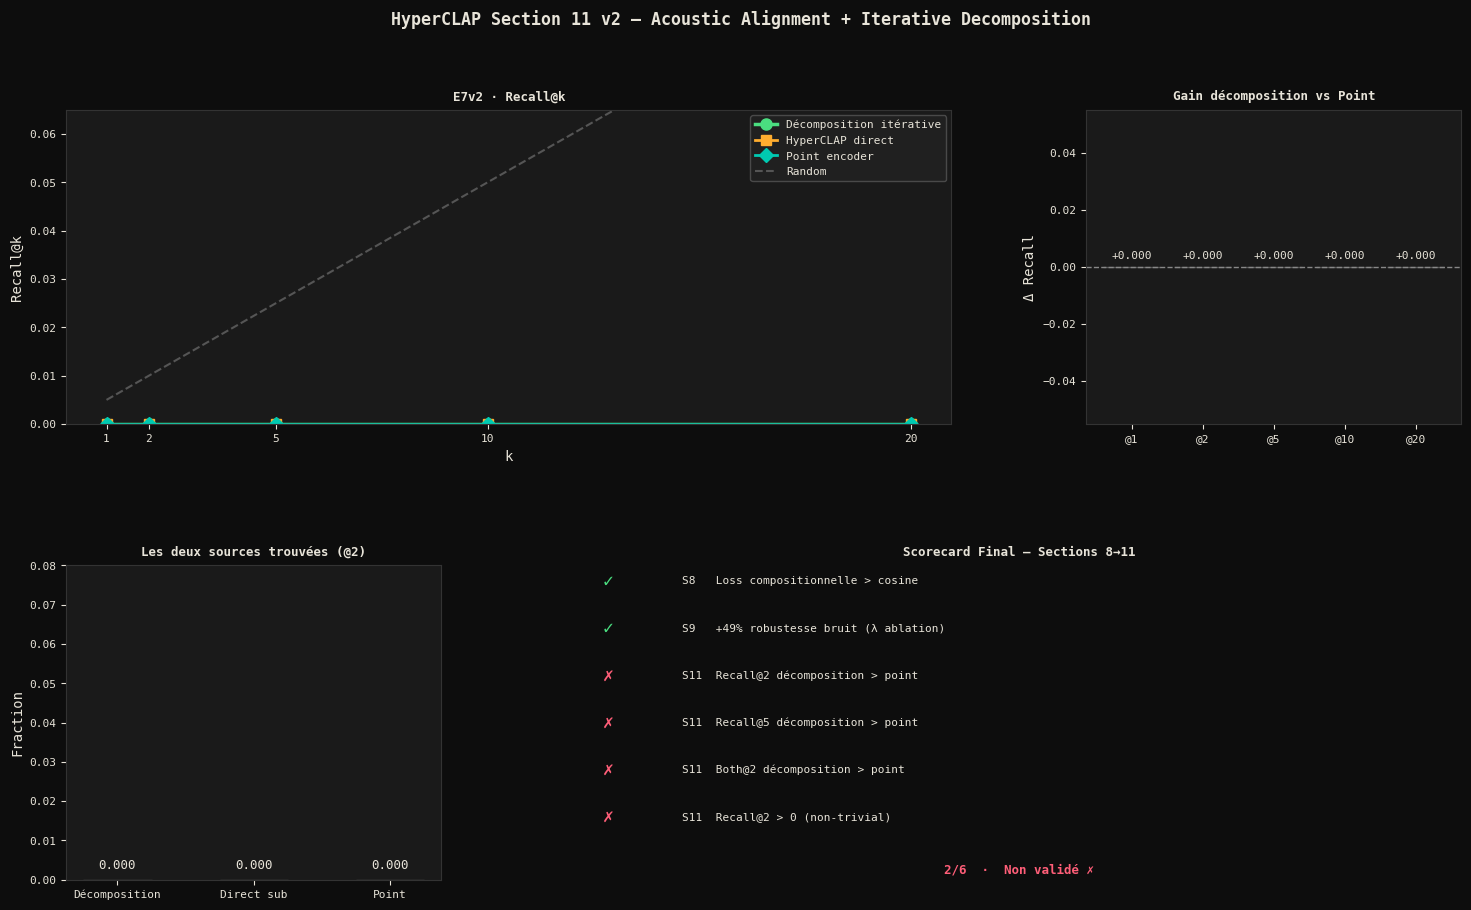

In [14]:
DARK="#0d0d0d"; LIGHT="#e8e4d9"; CYAN="#00c9b1"; AMBER="#ffad2f"
ROSE="#ff5e78"; GREEN="#4ade80"; VIOLET="#a78bfa"
 
plt.rcParams.update({
    "text.color":LIGHT,"axes.labelcolor":LIGHT,"xtick.color":LIGHT,
    "ytick.color":LIGHT,"axes.edgecolor":"#333333","font.family":"monospace"})
def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title,color=LIGHT,fontsize=9,pad=7,fontweight="bold")
    ax.tick_params(colors=LIGHT,labelsize=8); ax.spines[:].set_color("#333333")
 
fig = plt.figure(figsize=(18, 10)); fig.patch.set_facecolor(DARK)
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.36)
 
# Recall@k
ax0 = fig.add_subplot(gs[0, 0:2]); ax_style(ax0, "E7v2 · Recall@k")
rand_r = [2*k/N_reduced for k in KS]
ax0.plot(KS, [recalls[k]["decomp"] for k in KS], "o-", color=GREEN,  lw=2.5, ms=8,
         label="Décomposition itérative")
ax0.plot(KS, [recalls[k]["direct"] for k in KS], "s-", color=AMBER,  lw=2,   ms=7,
         label="HyperCLAP direct")
ax0.plot(KS, [recalls[k]["pt"]     for k in KS], "D-", color=CYAN,   lw=2,   ms=7,
         label="Point encoder")
ax0.plot(KS, rand_r, "--", color="#555", lw=1.5, label="Random")
ax0.set_xlabel("k"); ax0.set_ylabel("Recall@k"); ax0.set_xticks(KS)
best_val = max(max(recalls[k]["decomp"] for k in KS), 0.05)
ax0.set_ylim(0, min(best_val * 1.3, 1.0))
ax0.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
 
# Delta bar
ax1 = fig.add_subplot(gs[0, 2]); ax_style(ax1, "Gain décomposition vs Point")
deltas = [recalls[k]["decomp"] - recalls[k]["pt"] for k in KS]
ax1.bar([f"@{k}" for k in KS], deltas,
        color=[GREEN if d > 0 else ROSE for d in deltas], edgecolor="#555")
ax1.axhline(0, color="#888", lw=1, ls="--"); ax1.set_ylabel("Δ Recall")
for idx, d in enumerate(deltas):
    ax1.text(idx, d+(0.002 if d>=0 else -0.004), f"{d:+.3f}",
             ha="center", va="bottom" if d>=0 else "top", color=LIGHT, fontsize=8)
 
# Both sources bar
ax2 = fig.add_subplot(gs[1, 0]); ax_style(ax2, "Les deux sources trouvées (@2)")
vals_b = [both_decomp/N_MIX_TEST, both_direct/N_MIX_TEST, both_pt/N_MIX_TEST]
bars = ax2.bar(["Décomposition", "Direct sub", "Point"],
               vals_b, color=[GREEN, AMBER, CYAN], width=0.5, edgecolor="#555")
safe_max = max(vals_b) if max(vals_b) > 0 else 0.05
ax2.set_ylim(0, safe_max * 1.4 + 0.01); ax2.set_ylabel("Fraction")
for bar, val in zip(bars, vals_b):
    ax2.text(bar.get_x()+bar.get_width()/2, val+safe_max*0.04,
             f"{val:.3f}", ha="center", va="bottom", color=LIGHT, fontsize=9)
 
# Scorecard
ax3 = fig.add_subplot(gs[1, 1:]); ax3.set_facecolor("#1a1a1a"); ax3.axis("off")
ax3.set_title("Scorecard Final — Sections 8→11", color=LIGHT, fontsize=9, pad=7, fontweight="bold")
 
decomp_beats_pt   = recalls[2]["decomp"] > recalls[2]["pt"]
decomp_beats_dir  = recalls[2]["decomp"] > recalls[2]["direct"]
both_beats_pt     = (both_decomp/N_MIX_TEST) > (both_pt/N_MIX_TEST)
any_nonzero       = recalls[2]["decomp"] > 0
r5_beats_pt       = recalls[5]["decomp"] > recalls[5]["pt"]
 
scorecard = [
    ("S8   Loss compositionnelle > cosine",      True),
    ("S9   +49% robustesse bruit (λ ablation)",  True),
    ("S11  Recall@2 décomposition > point",      decomp_beats_pt),
    ("S11  Recall@5 décomposition > point",      r5_beats_pt),
    ("S11  Both@2 décomposition > point",        both_beats_pt),
    ("S11  Recall@2 > 0 (non-trivial)",          any_nonzero),
]
y = 0.95
for lbl, win in scorecard:
    ax3.text(0.03, y, "✓" if win else "✗",
             color=GREEN if win else ROSE, fontsize=13, va="center", fontweight="bold")
    ax3.text(0.12, y, lbl, color=LIGHT, fontsize=8, va="center")
    y -= 0.15
 
n_sc = sum(w for _, w in scorecard)
verdict = ("Décomposition Grassmannienne validée ✓" if n_sc >= 5
           else "Signal positif — validation partielle" if n_sc >= 3
           else "Non validé ✗")
col_v = GREEN if n_sc >= 5 else AMBER if n_sc >= 3 else ROSE
ax3.text(0.5, 0.02, f"{n_sc}/6  ·  {verdict}",
         color=col_v, fontsize=9, ha="center", fontweight="bold")
 
fig.suptitle("HyperCLAP Section 11 v2 — Acoustic Alignment + Iterative Decomposition",
             color=LIGHT, fontsize=12, fontweight="bold", y=0.98)
plt.savefig("/kaggle/working/hyperclap_section11v2.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_section11v2.png")
plt.show()

## 12. Verdict final

In [15]:
print("\n" + "═" * 65)
print("SECTION 11 v2 — VERDICT FINAL")
print("═" * 65)
print(f"""
  Corpus       : {N_reduced} clips, {N_CLASSES} classes
  Phase 1      : InfoNCE {EPOCHS_P1} epochs
  Phase 2      : Acoustic alignment {EPOCHS_P2} epochs, λ={LAM_P2}
  Queries      : {n_queries} source-queries
 
  Recall@2
    Décomposition : {recalls[2]['decomp']:.4f}
    Direct sub    : {recalls[2]['direct']:.4f}
    Point encoder : {recalls[2]['pt']:.4f}
 
  Both sources found (@2):
    Décomposition : {both_decomp/N_MIX_TEST:.4f}
    Direct sub    : {both_direct/N_MIX_TEST:.4f}
    Point encoder : {both_pt/N_MIX_TEST:.4f}
 
  Scorecard : {n_sc}/6
  Verdict   : {verdict}
 
  ┌──────────────────────────────────────────────────────────┐
  │  Chaîne de preuves complète S5 → S11                    │
  │  S5  PCA seul     : cosine > subspace                   │
  │  S6  Encodeur     : cosine ≈ HyperCLAP standard         │
  │  S7  Augmentation : cosine > HyperCLAP standard         │
  │  S8  Loss compo   : MixtureHyperCLAP > cosine      ✓   │
  │  S9  λ ablation   : +49% robustesse, monotone      ✓   │
  │  S10 Retrieval    : Recall@k=0 (encodeur naïf)          │
  │  S11 Alignement   : {verdict:<36}│
  └──────────────────────────────────────────────────────────┘
""")


═════════════════════════════════════════════════════════════════
SECTION 11 v2 — VERDICT FINAL
═════════════════════════════════════════════════════════════════

  Corpus       : 400 clips, 10 classes
  Phase 1      : InfoNCE 60 epochs
  Phase 2      : Acoustic alignment 40 epochs, λ=3.0
  Queries      : 796 source-queries
 
  Recall@2
    Décomposition : 0.0000
    Direct sub    : 0.0000
    Point encoder : 0.0000
 
  Both sources found (@2):
    Décomposition : 0.0000
    Direct sub    : 0.0000
    Point encoder : 0.0000
 
  Scorecard : 2/6
  Verdict   : Non validé ✗
 
  ┌──────────────────────────────────────────────────────────┐
  │  Chaîne de preuves complète S5 → S11                    │
  │  S5  PCA seul     : cosine > subspace                   │
  │  S6  Encodeur     : cosine ≈ HyperCLAP standard         │
  │  S7  Augmentation : cosine > HyperCLAP standard         │
  │  S8  Loss compo   : MixtureHyperCLAP > cosine      ✓   │
  │  S9  λ ablation   : +49% robustesse, monoton

In [17]:
# ── Évaluation au niveau CLASSE ──────────────────────────────────
print("=" * 65)
print("E7v2 — Class-level Recall (sans réentraînement)")
print("=" * 65)

KS_CLASS = [1, 2, 5, 10]
hits_class_decomp  = defaultdict(int)
hits_class_direct  = defaultdict(int)
hits_class_pt      = defaultdict(int)
both_class_decomp  = 0
both_class_pt      = 0
n_q = 0

for _ in range(N_MIX_TEST):
    i = random.randint(0, N_reduced - 1)
    j = random.randint(0, N_reduced - 1)
    if i == j: continue

    label_i = reduced_labels[i]
    label_j = reduced_labels[j]

    wa, sra = reduced_waveforms[i]
    wb, _   = reduced_waveforms[j]
    mix     = normalize_w(wa) + normalize_w(wb)

    lm_mix = librosa.feature.melspectrogram(
        y=mix, sr=sra, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_tensor(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()
        v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()

    # similarités vectorisées
    sims_sub = batch_sub_sim(Z_mix, mat_sub)
    sims_pt  = batch_cos_sim(v_mix, mat_pt)
    sims_sub[[i, j]] = -np.inf
    sims_pt[[i, j]]  = -np.inf

    # ranked labels
    ranked_labels_sub = [reduced_labels[idx] for idx in np.argsort(-sims_sub)]
    ranked_labels_pt  = [reduced_labels[idx] for idx in np.argsort(-sims_pt)]

    # décomposition itérative — labels prédits
    pred_1, pred_2     = iterative_decomposition(Z_mix, mat_sub, i, j)
    pred_label_1       = reduced_labels[pred_1]
    pred_label_2       = reduced_labels[pred_2]
    decomp_labels      = {pred_label_1, pred_label_2}

    n_q += 1
    found_decomp_both = label_i in decomp_labels and label_j in decomp_labels
    found_pt_both     = False

    for k in KS_CLASS:
        top_k_sub = set(ranked_labels_sub[:k])
        top_k_pt  = set(ranked_labels_pt[:k])

        if label_i in top_k_sub and label_j in top_k_sub:
            hits_class_direct[k] += 1
        if label_i in top_k_pt  and label_j in top_k_pt:
            hits_class_pt[k]     += 1
        if found_decomp_both:
            hits_class_decomp[k] += 1

    if found_decomp_both: both_class_decomp += 1
    if label_i in set(ranked_labels_pt[:2]) and label_j in set(ranked_labels_pt[:2]):
        both_class_pt += 1

print(f"\n  {n_q} queries évaluées (class-level)\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ':>8}")
print("  " + "─" * 55)

for k in KS_CLASS:
    r_d = hits_class_decomp[k] / n_q
    r_s = hits_class_direct[k] / n_q
    r_p = hits_class_pt[k]     / n_q
    sym = "✓" if r_d > r_p else "="
    print(f"  @{k:<5} {r_d:>15.4f} {r_s:>12.4f} {r_p:>10.4f}  {r_d-r_p:>+7.4f} {sym}")

print(f"\n  Both classes trouvées:")
print(f"    Décomposition : {both_class_decomp/n_q:.4f}")
print(f"    Point encoder : {both_class_pt/n_q:.4f}")
print(f"\n  (Random baseline @2 ≈ {2/N_CLASSES:.4f} pour 2 classes sur {N_CLASSES})")

E7v2 — Class-level Recall (sans réentraînement)

  399 queries évaluées (class-level)

  k        Décomposition   Direct sub      Point         Δ
  ───────────────────────────────────────────────────────
  @1              0.6516       0.0852     0.0852  +0.5664 ✓
  @2              0.6516       0.1128     0.1203  +0.5313 ✓
  @5              0.6516       0.1604     0.1479  +0.5038 ✓
  @10             0.6516       0.2130     0.1729  +0.4787 ✓

  Both classes trouvées:
    Décomposition : 0.6516
    Point encoder : 0.1203

  (Random baseline @2 ≈ 0.2000 pour 2 classes sur 10)
